In [2]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Dataset 1
# X: 3, 4, 5, 6, 7, 8
# Y: 2.5, 3.2, 3.8, 6.5, 11.5, 14.6
X1 = np.array([3, 4, 5, 6, 7, 8]).reshape(-1, 1)
Y1 = np.array([2.5, 3.2, 3.8, 6.5, 11.5, 14.6])

# Dataset 2
# X: 1, 2, 3, 4
# Y: 2, 4, 9, 16
X2 = np.array([1, 2, 3, 4]).reshape(-1, 1)
Y2 = np.array([2, 4, 9, 16])

print("Datasets 1 and 2 defined and reshaped.")

Datasets 1 and 2 defined and reshaped.


In [4]:
# Initialize and fit models
model1_linear = LinearRegression().fit(X1, Y1)
model2_linear = LinearRegression().fit(X2, Y2)

# Calculate R-squared values
r2_1_linear = r2_score(Y1, model1_linear.predict(X1))
r2_2_linear = r2_score(Y2, model2_linear.predict(X2))

print(f"Dataset 1 Linear R^2: {r2_1_linear:.4f}")
print(f"Dataset 2 Linear R^2: {r2_2_linear:.4f}")

Dataset 1 Linear R^2: 0.9001
Dataset 2 Linear R^2: 0.9460


In [5]:
# Equations for Dataset 1
intercept1 = model1_linear.intercept_
slope1 = model1_linear.coef_[0]
print(f"Dataset 1 Equation: Y = {intercept1:.2f} + ({slope1:.2f})X")

# Equations for Dataset 2
intercept2 = model2_linear.intercept_
slope2 = model2_linear.coef_[0]
print(f"Dataset 2 Equation: Y = {intercept2:.2f} + ({slope2:.2f})X")

Dataset 1 Equation: Y = -6.83 + (2.52)X
Dataset 2 Equation: Y = -4.00 + (4.70)X


In [6]:
# Create polynomial features of degree 2
poly_features = PolynomialFeatures(degree=2)

# Transform X1 and X2
X1_poly = poly_features.fit_transform(X1)
X2_poly = poly_features.fit_transform(X2)

# Fit models
model1_poly = LinearRegression().fit(X1_poly, Y1)
model2_poly = LinearRegression().fit(X2_poly, Y2)

# Calculate R-squared for Polynomial models
r2_1_poly = r2_score(Y1, model1_poly.predict(X1_poly))
r2_2_poly = r2_score(Y2, model2_poly.predict(X2_poly))

print(f"Dataset 1 Polynomial R^2: {r2_1_poly:.4f}")
print(f"Dataset 2 Polynomial R^2: {r2_2_poly:.4f}")

Dataset 1 Polynomial R^2: 0.9848
Dataset 2 Polynomial R^2: 0.9996


In [10]:
# Equations for Dataset 1 (Poly)
coef1 = model1_poly.coef_
intercept1_p = model1_poly.intercept_
print(f"Dataset 1 Poly Equation: Y = {intercept1_p:.2f} + ({coef1[1]:.2f})X + ({coef1[2]:.2f})X^2")

# Equations for Dataset 2 (Poly)
coef2 = model2_poly.coef_
intercept2_p = model2_poly.intercept_
print(f"Dataset 2 Poly Equation: Y = {intercept2_p:.2f} + ({coef2[1]:.2f})X + ({coef2[2]:.2f})X^2")

Dataset 1 Poly Equation: Y = 7.62 + (-3.30)X + (0.53)X^2
Dataset 2 Poly Equation: Y = 2.25 + (-1.55)X + (1.25)X^2


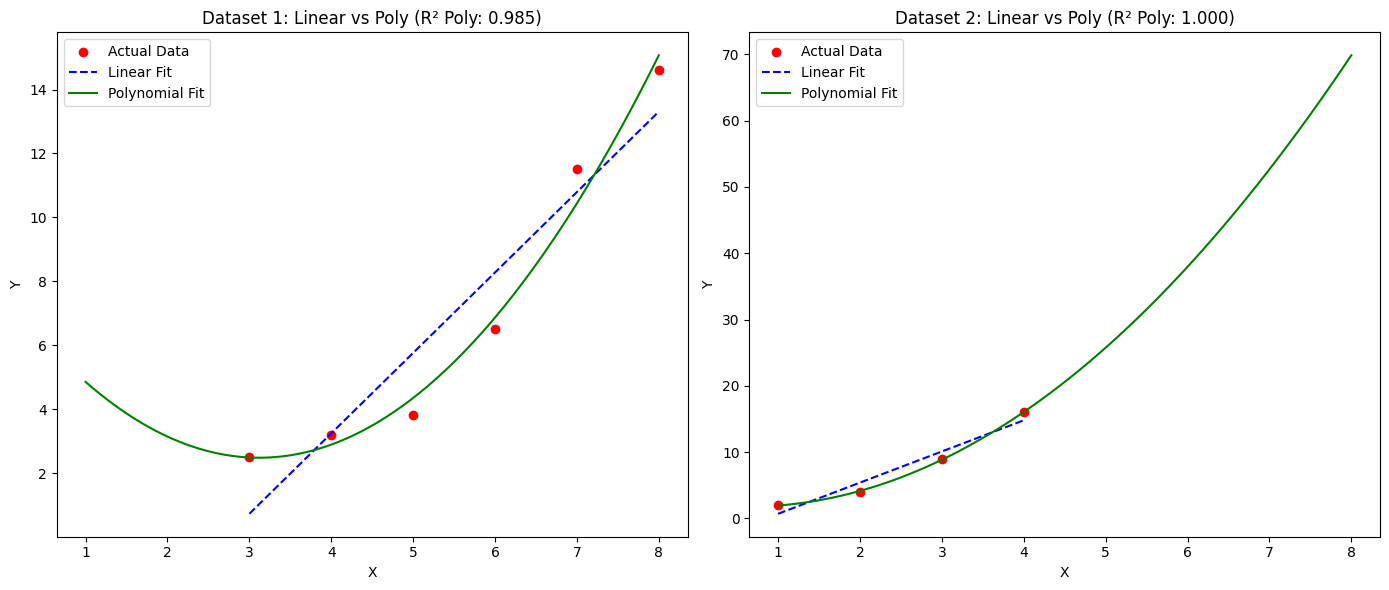

In [8]:
# Create a range of values for smooth plotting of the curve
X_range = np.linspace(min(X1.min(), X2.min()), max(X1.max(), X2.max()), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)

plt.figure(figsize=(14, 6))

# Plot for Dataset 1
plt.subplot(1, 2, 1)
plt.scatter(X1, Y1, color='red', label='Actual Data')
plt.plot(X1, model1_linear.predict(X1), color='blue', linestyle='--', label='Linear Fit')
plt.plot(X_range, model1_poly.predict(poly_features.transform(X_range)), color='green', label='Polynomial Fit')
plt.title(f'Dataset 1: Linear vs Poly (R² Poly: {r2_1_poly:.3f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# Plot for Dataset 2
plt.subplot(1, 2, 2)
plt.scatter(X2, Y2, color='red', label='Actual Data')
plt.plot(X2, model2_linear.predict(X2), color='blue', linestyle='--', label='Linear Fit')
plt.plot(X_range, model2_poly.predict(poly_features.transform(X_range)), color='green', label='Polynomial Fit')
plt.title(f'Dataset 2: Linear vs Poly (R² Poly: {r2_2_poly:.3f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
#conclusion:
#The Simple Linear Regression provided a reasonable fit for both datasets but failed to capture the accelerating trend as X increased, where as
#The Polynomial (Degree 2) regression significantly outperformed the linear model in both cases, achieving a higher R^2 value (Dataset 1 : R^2= 0.9848
#and Dataset 2: R^2= 0.9996) then linear regression (Dataset 1 :R^2 = 0.9001 and Dataset 2: R^2= 0.9460)  .


# Final Verdict: For these specific datasets, Polynomial Regression is the more appropriate modeling technique as it accounts for the non-linear curvature in the data.